total_steps: 10.0
dt_per_segment (t-space): 1.5232
velocity scale factor: 0.1523
example pos diff: 2.0555
example vel magnitude (scaled): 0.2154

Linear  RMSE: 2.671353
Hermite RMSE: 2.713649


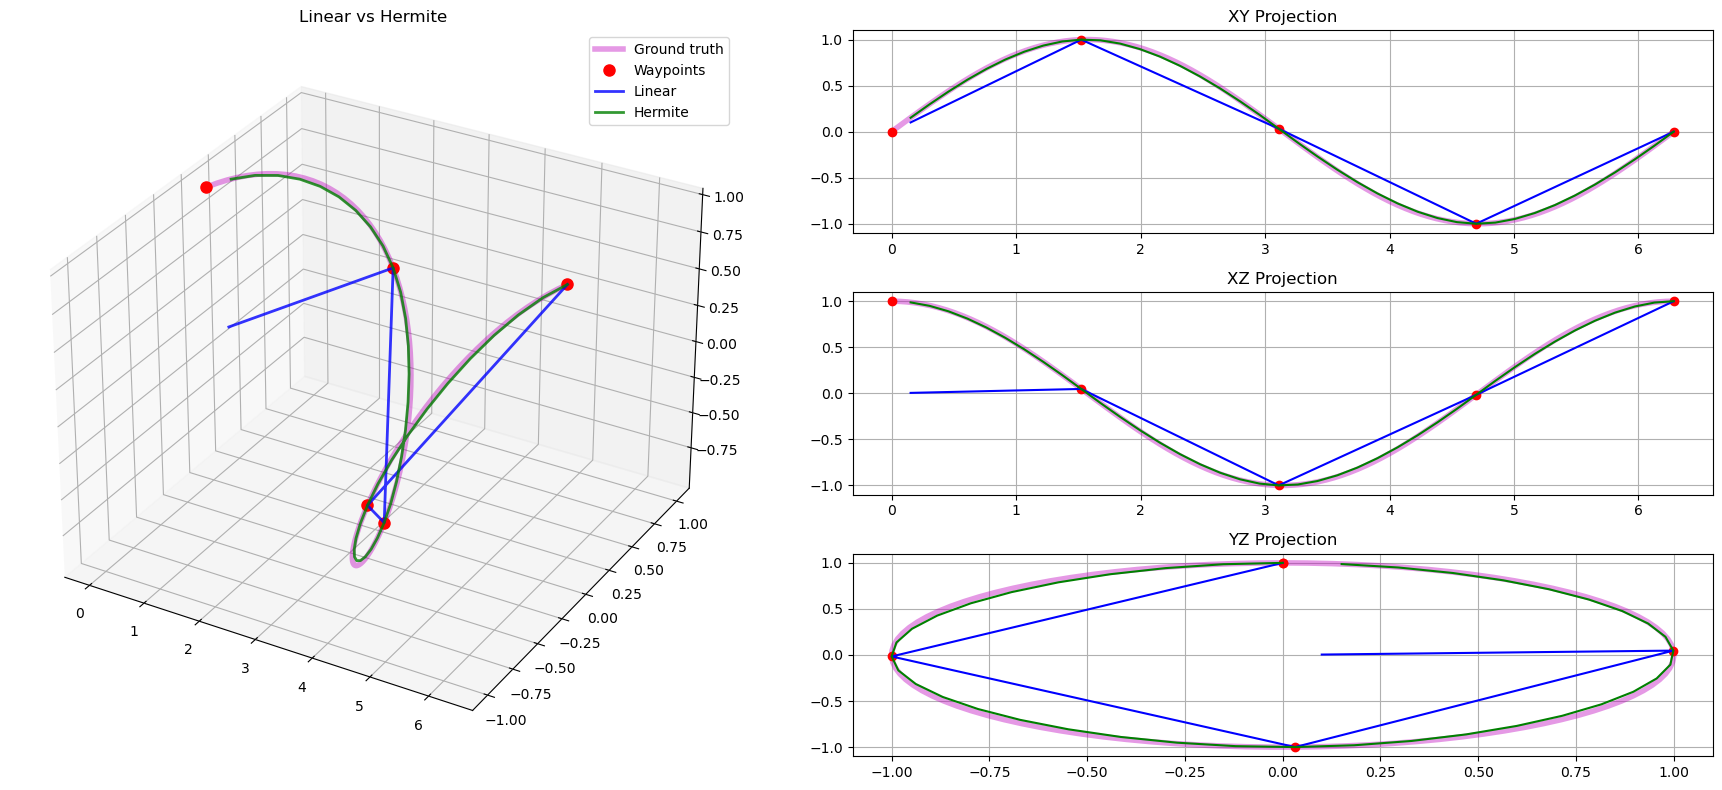

In [1]:
import sys
sys.path.insert(0, '/home/denizsen/awe/robosuite')
import numpy as np
import matplotlib.pyplot as plt
from robosuite.controllers.interpolators.linear_interpolator import LinearInterpolator
from robosuite.controllers.interpolators.hermite_spline_interpolator import HermiteSplineInterpolator

def compare_interpolation():
    # synthetic trajectory
    dense_steps = 100
    t           = np.linspace(0, 2*np.pi, dense_steps)
    dense_ref   = np.column_stack([t, np.sin(t), np.cos(t)])
    dense_vel   = np.column_stack([np.ones(dense_steps), np.cos(t), -np.sin(t)])

    # sparse waypoints
    num_waypoints    = 5
    waypoint_indices = np.linspace(0, dense_steps - 1, num_waypoints).astype(int)
    waypoints        = dense_ref[waypoint_indices]
    waypoint_vels    = dense_vel[waypoint_indices]

    # linear interpolation
    lin = LinearInterpolator(ndim=3, controller_freq=100, policy_freq=20, ramp_ratio=2.0)
    lin_points = []
    for i in range(num_waypoints - 1):
        lin.start = np.array(waypoints[i])
        lin.set_goal(waypoints[i + 1])
        for _ in range(int(lin.total_steps)):
            lin_points.append(lin.get_interpolated_goal())
    lin_points = np.array(lin_points)

    # hermite interpolation
    her = HermiteSplineInterpolator(ndim=3, controller_freq=100, policy_freq=20, ramp_ratio=2.0)

    # scale velocity from "per t-unit" to "per step"
    # t spans [0, 2pi] over 100 steps, so dt between consecutive waypoints in t-space:
    dt_per_segment    = t[waypoint_indices[1]] - t[waypoint_indices[0]]  # t-space gap
    scale             = dt_per_segment / her.total_steps  # t-units per step
    scaled_vels       = waypoint_vels * scale

    print(f"total_steps: {her.total_steps}")
    print(f"dt_per_segment (t-space): {dt_per_segment:.4f}")
    print(f"velocity scale factor: {scale:.4f}")
    print(f"example pos diff: {np.linalg.norm(waypoints[1] - waypoints[0]):.4f}")
    print(f"example vel magnitude (scaled): {np.linalg.norm(scaled_vels[0]):.4f}")

    her_points = []
    for i in range(num_waypoints - 1):
        her.set_goal(
            goal      = waypoints[i + 1],
            start     = waypoints[i],
            start_vel = scaled_vels[i],
            goal_vel  = scaled_vels[i + 1],
        )
        for _ in range(int(her.total_steps)):
            her_points.append(her.get_interpolated_goal())
    her_points = np.array(her_points)

    # errors
    n = min(len(lin_points), len(her_points))
    def rmse(a, b): return np.sqrt(np.mean(np.sum((a - b)**2, axis=1)))
    print(f"\nLinear  RMSE: {rmse(dense_ref[:n], lin_points[:n]):.6f}")
    print(f"Hermite RMSE: {rmse(dense_ref[:n], her_points[:n]):.6f}")

    # plot 
    fig = plt.figure(figsize=(18, 8))
    ax  = fig.add_subplot(121, projection='3d')
    ax.plot(dense_ref[:, 0], dense_ref[:, 1], dense_ref[:, 2],
            'm-', label='Ground truth', alpha=0.4, linewidth=4)
    ax.plot(waypoints[:, 0], waypoints[:, 1], waypoints[:, 2],
            'ro', label='Waypoints', markersize=8)
    ax.plot(lin_points[:, 0], lin_points[:, 1], lin_points[:, 2],
            'b-', label='Linear', alpha=0.8, linewidth=2)
    ax.plot(her_points[:, 0], her_points[:, 1], her_points[:, 2],
            'g-', label='Hermite', alpha=0.8, linewidth=2)
    ax.set_title('Linear vs Hermite')
    ax.legend()

    # 2D projections
    ax2 = fig.add_subplot(322)
    ax2.plot(dense_ref[:, 0], dense_ref[:, 1], 'm-', alpha=0.4, linewidth=4)
    ax2.plot(waypoints[:, 0], waypoints[:, 1], 'ro')
    ax2.plot(lin_points[:, 0], lin_points[:, 1], 'b-')
    ax2.plot(her_points[:, 0], her_points[:, 1], 'g-')
    ax2.set_title('XY Projection')
    ax2.grid(True)

    ax3 = fig.add_subplot(324)
    ax3.plot(dense_ref[:, 0], dense_ref[:, 2], 'm-', alpha=0.4, linewidth=4)
    ax3.plot(waypoints[:, 0], waypoints[:, 2], 'ro')
    ax3.plot(lin_points[:, 0], lin_points[:, 2], 'b-')
    ax3.plot(her_points[:, 0], her_points[:, 2], 'g-')
    ax3.set_title('XZ Projection')
    ax3.grid(True)

    ax4 = fig.add_subplot(326)
    ax4.plot(dense_ref[:, 1], dense_ref[:, 2], 'm-', alpha=0.4, linewidth=4)
    ax4.plot(waypoints[:, 1], waypoints[:, 2], 'ro')
    ax4.plot(lin_points[:, 1], lin_points[:, 2], 'b-')
    ax4.plot(her_points[:, 1], her_points[:, 2], 'g-')
    ax4.set_title('YZ Projection')
    ax4.grid(True)

    plt.tight_layout()
    plt.show()

compare_interpolation()